EXPERIMENT 07 - TASK 02
Grid Search Hyperparameter Optimization
Name    : R. Karthik
Roll No : 25EU02904

Default SVM Accuracy: 84.13%

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Grid Search Accuracy: 92.06%
Best Cross-Validation Score: 82.76%

Performance Comparison:
          Model  Accuracy (%)
    Default SVM         84.13
Grid Search SVM         92.06


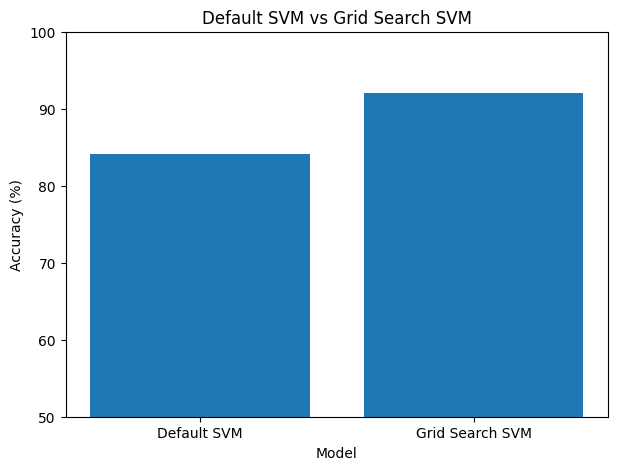


TASK 02 COMPLETED
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 07 - TASK 02
# Hyperparameter Optimization using Grid Search
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

print("=" * 60)
print("EXPERIMENT 07 - TASK 02")
print("Grid Search Hyperparameter Optimization")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# Load Sonar Dataset
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

features = [
    f"F_{i}"
    for i in range(1, 61)
]

columns = features + ["Class"]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

df["Target"] = df["Class"].map({
    "M": 1,
    "R": 0
})

X = df[features]

y = df["Target"]

# ------------------------------------------------------------
# Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Default SVM
# ------------------------------------------------------------

default_model = SVC(
    probability=True,
    random_state=42
)

default_model.fit(
    X_train,
    y_train
)

default_pred = default_model.predict(
    X_test
)

default_accuracy = accuracy_score(
    y_test,
    default_pred
)

print(
    f"\nDefault SVM Accuracy: "
    f"{default_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

param_grid = {
    "C": [
        0.1,
        1,
        10,
        100
    ],
    "gamma": [
        "scale",
        "auto",
        0.01,
        0.1,
        1
    ],
    "kernel": [
        "linear",
        "rbf"
    ]
}

grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

best_model = grid.best_estimator_

grid_pred = best_model.predict(
    X_test
)

grid_accuracy = accuracy_score(
    y_test,
    grid_pred
)

print("\nBest Parameters:")
print(
    grid.best_params_
)

print(
    f"\nGrid Search Accuracy: "
    f"{grid_accuracy * 100:.2f}%"
)

print(
    f"Best Cross-Validation Score: "
    f"{grid.best_score_ * 100:.2f}%"
)

# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Default SVM",
        "Grid Search SVM"
    ],
    "Accuracy (%)": [
        default_accuracy * 100,
        grid_accuracy * 100
    ]
})

print("\nPerformance Comparison:")
print(
    comparison.round(2).to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Graph
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Default SVM vs Grid Search SVM"
)

plt.ylim(
    50,
    100
)

plt.show()

print("\n" + "=" * 60)
print("TASK 02 COMPLETED")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)